In [ ]:
# =============================================================================
# AGMTL-DenseCBAM: Attention-Guided Multi-Task Learning DenseNet with CBAM
# For Robust Temporomandibular Disorder Classification
# =============================================================================
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Layer, Conv2D, Dense, GlobalAveragePooling2D, Multiply, Reshape,
    Dropout, BatchNormalization, Flatten
)
from tensorflow.keras.regularizers import l2
import warnings
warnings.filterwarnings("ignore")

sns.set_style('darkgrid')

I0000 00:00:1776605106.634850    8611 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776605107.396054    8611 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776605110.103623    8611 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 8
EPOCHS = 50
LEARNING_RATE = 1e-4
USE_CBAM = True                 # Set to False to use baseline self-attention
USE_MTL = False                 # Set to True for multi-task learning with artifact head
ARTIFACT_CLASSES = 4            # None, Motion Blur, Gaussian Noise, Metal Streak
AUX_LOSS_WEIGHT = 0.3           # Weight for auxiliary task loss

In [3]:
# =============================================================================
# DATA LOADING
# =============================================================================
tr_gen = ImageDataGenerator(rescale=1.0/255.0, horizontal_flip=True)
tst_gen = ImageDataGenerator(rescale=1.0/255.0)

train_gen = tr_gen.flow_from_directory(
    'data/train',
    target_size=IMG_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    batch_size=BATCH_SIZE
)

val_gen = tr_gen.flow_from_directory(
    'data/validation',
    target_size=IMG_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=BATCH_SIZE
)

test_gen = tst_gen.flow_from_directory(
    'data/test',
    target_size=IMG_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False,
    batch_size=BATCH_SIZE
)

Found 2191 images belonging to 2 classes.
Found 547 images belonging to 2 classes.
Found 687 images belonging to 2 classes.


In [4]:
# =============================================================================
# CORRECTED CBAM IMPLEMENTATION (Keras/TensorFlow)
# Based on: Woo et al. (2018) - https://arxiv.org/abs/1807.06521
# =============================================================================

from tensorflow.keras.layers import (
    Layer, Conv2D, Dense, GlobalAveragePooling2D, GlobalMaxPooling2D,
    Multiply, Add, Reshape, Concatenate, Activation, Lambda
)
from tensorflow.keras import backend as K

class AttentionBlock(Layer):
    def __init__(self, attention_type="cbam", reduction_ratio=16, **kwargs):
        super(AttentionBlock, self).__init__(**kwargs)
        self.attention_type = attention_type.lower()
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        filters = input_shape[-1]
        reduced_filters = max(filters // self.reduction_ratio, 1)

        if self.attention_type == "cbam":
            # Channel Attention Shared MLP
            self.channel_dense1 = Dense(reduced_filters, activation='relu', kernel_initializer='he_normal')
            self.channel_dense2 = Dense(filters, kernel_initializer='he_normal')
            self.avg_pool = GlobalAveragePooling2D()
            self.max_pool = GlobalMaxPooling2D()
            
            # Spatial Attention Conv Layer
            self.spatial_conv = Conv2D(1, (7, 7), padding='same', activation='sigmoid', kernel_initializer='he_normal')

        elif self.attention_type == "self":
            self.query_conv = Conv2D(filters // 8, (1, 1), padding="same")
            self.key_conv = Conv2D(filters // 8, (1, 1), padding="same")
            self.value_conv = Conv2D(filters, (1, 1), padding="same")

    def call(self, inputs):
        if self.attention_type == "cbam":
            # --- 1. Channel Attention ---
            # Average Pooling branch
            avg_pool = self.avg_pool(inputs)
            avg_pool = Reshape((1, 1, -1))(avg_pool)
            avg_pool = self.channel_dense1(avg_pool)
            avg_pool = self.channel_dense2(avg_pool)
            
            # Max Pooling branch
            max_pool = self.max_pool(inputs)
            max_pool = Reshape((1, 1, -1))(max_pool)
            max_pool = self.channel_dense1(max_pool)
            max_pool = self.channel_dense2(max_pool)
            
            # Combine and apply sigmoid
            channel_attention = Add()([avg_pool, max_pool])
            channel_attention = Activation('sigmoid')(channel_attention)
            x = Multiply()([inputs, channel_attention])
            
            # --- 2. Spatial Attention ---
            # Average and Max across channels
            avg_pool_spatial = Lambda(lambda z: K.mean(z, axis=-1, keepdims=True))(x)
            max_pool_spatial = Lambda(lambda z: K.max(z, axis=-1, keepdims=True))(x)
            
            # Concatenate and apply 7x7 Conv
            concat_spatial = Concatenate(axis=-1)([avg_pool_spatial, max_pool_spatial])
            spatial_attention = self.spatial_conv(concat_spatial)
            x = Multiply()([x, spatial_attention])
            
            return x

        elif self.attention_type == "self":
            batch_size, h, w, c = tf.shape(inputs)[0], inputs.shape[1], inputs.shape[2], inputs.shape[3]
            query = self.query_conv(inputs)
            key = self.key_conv(inputs)
            value = self.value_conv(inputs)

            query = tf.reshape(query, (batch_size, h*w, -1))
            key = tf.reshape(key, (batch_size, h*w, -1))
            value = tf.reshape(value, (batch_size, h*w, -1))

            attention = tf.nn.softmax(tf.matmul(query, key, transpose_b=True) / tf.sqrt(tf.cast(c, tf.float32)))
            out = tf.matmul(attention, value)
            out = tf.reshape(out, (batch_size, h, w, -1))
            return inputs + out

In [5]:
# =============================================================================
# MODEL BUILDERS
# =============================================================================

def build_single_task_model(use_cbam=True):
    """Single-task model: DenseNet201 + Attention → Normal/Subluxation"""
    base_model = tf.keras.applications.DenseNet201(
        include_top=False,
        weights='imagenet',
        input_shape=(*IMG_SIZE, 3),
        pooling=None
    )

    # Apply attention to the final convolutional block features
    x = base_model.get_layer("conv5_block32_concat").output  # Shape: (7,7,1920)

    if use_cbam:
        x = AttentionBlock(attention_type="cbam")(x)
    else:
        x = AttentionBlock(attention_type="self")(x)

    # Classifier head
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    x = BatchNormalization()(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(2, activation='softmax', name='tmd_output')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    return model


def build_mtl_model(use_cbam=True, num_artifact_classes=4):
    """Multi-task model: DenseNet201 + Attention → TMD (2) + Artifact (N)"""
    base_model = tf.keras.applications.DenseNet201(
        include_top=False,
        weights='imagenet',
        input_shape=(*IMG_SIZE, 3),
        pooling=None
    )

    x = base_model.get_layer("conv5_block32_concat").output

    if use_cbam:
        x = AttentionBlock(attention_type="cbam")(x)
    else:
        x = AttentionBlock(attention_type="self")(x)

    shared = GlobalAveragePooling2D()(x)

    # Primary head: TMD classification
    primary = Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(shared)
    primary = Dropout(0.5)(primary)
    primary = BatchNormalization()(primary)
    primary = Dense(128, activation='relu')(primary)
    tmd_output = Dense(2, activation='softmax', name='tmd_output')(primary)

    # Auxiliary head: Artifact detection
    aux = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(shared)
    aux = Dropout(0.3)(aux)
    artifact_output = Dense(num_artifact_classes, activation='softmax', name='artifact_output')(aux)

    model = Model(inputs=base_model.input, outputs=[tmd_output, artifact_output])
    return model

In [6]:
# =============================================================================
# BUILD MODEL
# =============================================================================
if USE_MTL:
    model = build_mtl_model(use_cbam=USE_CBAM, num_artifact_classes=ARTIFACT_CLASSES)
    losses = {
        'tmd_output': 'categorical_crossentropy',
        'artifact_output': 'categorical_crossentropy'
    }
    loss_weights = {'tmd_output': 1.0, 'artifact_output': AUX_LOSS_WEIGHT}
    metrics = {'tmd_output': ['accuracy']}
else:
    model = build_single_task_model(use_cbam=USE_CBAM)
    losses = 'categorical_crossentropy'
    loss_weights = None
    metrics = ['accuracy']

model.compile(
    optimizer=Adam(LEARNING_RATE),
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics
)

model.summary()

I0000 00:00:1776605113.705275    8611 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 20,879,901 (79.65 MB)

 Trainable params: 20,652,637 (78.78 MB)

 Non-trainable params: 227,264 (887.75 KB)

In [7]:
# =============================================================================
# TRAINING
# =============================================================================
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# For MTL, we need to provide both labels. Since current generators only give TMD labels,
# you must either:
# 1) Use a custom generator that yields (X, {'tmd_output': y_tmd, 'artifact_output': y_art})
# 2) For initial testing, use single-task mode with USE_MTL=False
# We'll assume single-task for this script.

if USE_MTL:
    raise NotImplementedError(
        "Multi-task training requires a custom data generator that provides artifact labels.\n"
        "Set USE_MTL=False for single-task CBAM training first."
    )

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)


Epoch 1/50


I0000 00:00:1776605122.089709    8611 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1776605211.793416    9929 service.cc:153] XLA service 0x700ff803bba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776605211.793901    9929 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.5.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776605215.288130    9929 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776605235.496577    9929 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776605241.197803    9929 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_134930__.1270
I0000 00:00:1776605398.756205   10358 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_add_sub

200/274 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.5267 - loss: 11.6393

I0000 00:00:1776606194.644032    9927 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_134930__.1270
I0000 00:00:1776606404.683373   23114 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_1', 316 bytes spill stores, 316 bytes spill loads

I0000 00:00:1776606411.289208   23114 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_compare_reduce_fusion_20', 64 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776606421.263950   23114 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_22', 232 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776606427.352055   23119 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_compare_reduce_fusion_25', 80 bytes spill stores, 8 bytes spill loads

I0000 00:00:17766064

274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5542 - loss: 10.9189

I0000 00:00:1776606789.544144    9926 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_146630__.27
I0000 00:00:1776606791.458383   33729 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_4', 48 bytes spill stores, 48 bytes spill loads

I0000 00:00:1776606806.425384    9926 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_4', 48 bytes spill stores, 48 bytes spill loads

I0000 00:00:1776606816.441064    9926 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_146630__.27


274/274 ━━━━━━━━━━━━━━━━━━━━ 1737s 3s/step - accuracy: 0.6490 - loss: 8.4299 - val_accuracy: 0.7057 - val_loss: 4.7710 - learning_rate: 1.0000e-04
Epoch 2/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 40s 146ms/step - accuracy: 0.8412 - loss: 3.0020 - val_accuracy: 0.8483 - val_loss: 1.9733 - learning_rate: 1.0000e-04
Epoch 3/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 39s 138ms/step - accuracy: 0.8722 - loss: 1.4015 - val_accuracy: 0.8739 - val_loss: 1.0950 - learning_rate: 1.0000e-04
Epoch 4/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 35s 128ms/step - accuracy: 0.8991 - loss: 0.7931 - val_accuracy: 0.8519 - val_loss: 0.7581 - learning_rate: 1.0000e-04
Epoch 5/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 35s 128ms/step - accuracy: 0.9215 - loss: 0.5026 - val_accuracy: 0.8940 - val_loss: 0.4965 - learning_rate: 1.0000e-04
Epoch 6/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 35s 129ms/step - accuracy: 0.9416 - loss: 0.3279 - val_accuracy: 0.8702 - val_loss: 0.4704 - learning_rate: 1.0000e-04
Epoch 7/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 34s 123ms/step - a

In [8]:
# =============================================================================
# EVALUATION
# =============================================================================
results = model.evaluate(test_gen, verbose=0)
print(f'\nTest Loss: {results[0]:.4f}, Test Accuracy: {results[1]:.4f}')

y_true = test_gen.classes
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

cm = confusion_matrix(y_true, y_pred)
if cm.shape == (2, 2):
    TN, FP, FN, TP = cm.ravel()
    specificity = TN / (TN + FP)
else:
    specificity = None

print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
if specificity is not None:
    print(f"Specificity: {specificity:.4f}")
print(f"F1 Score: {f1:.4f}")

I0000 00:00:1776607528.658384    9927 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_146630__.27
I0000 00:00:1776607531.033393   40155 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_3', 48 bytes spill stores, 48 bytes spill loads

I0000 00:00:1776607547.069841    9927 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_3', 48 bytes spill stores, 48 bytes spill loads




Test Loss: 0.3301, Test Accuracy: 0.9141


I0000 00:00:1776607569.478375    9927 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_205327__.16
I0000 00:00:1776607584.768924    9927 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_2', 48 bytes spill stores, 48 bytes spill loads



85/86 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

I0000 00:00:1776607600.076965    9928 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_213533__.16
I0000 00:00:1776607613.785865    9928 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_2', 48 bytes spill stores, 48 bytes spill loads



86/86 ━━━━━━━━━━━━━━━━━━━━ 66s 340ms/step
Precision: 0.9140
Recall (Sensitivity): 0.9141
Specificity: 0.8923
F1 Score: 0.9140


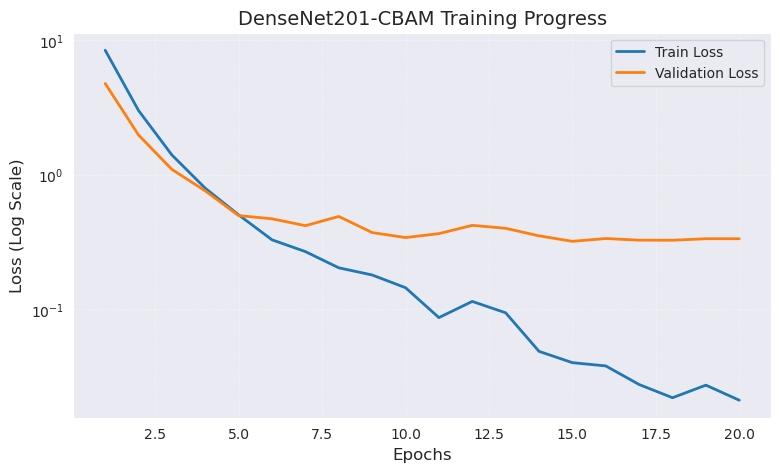

86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step


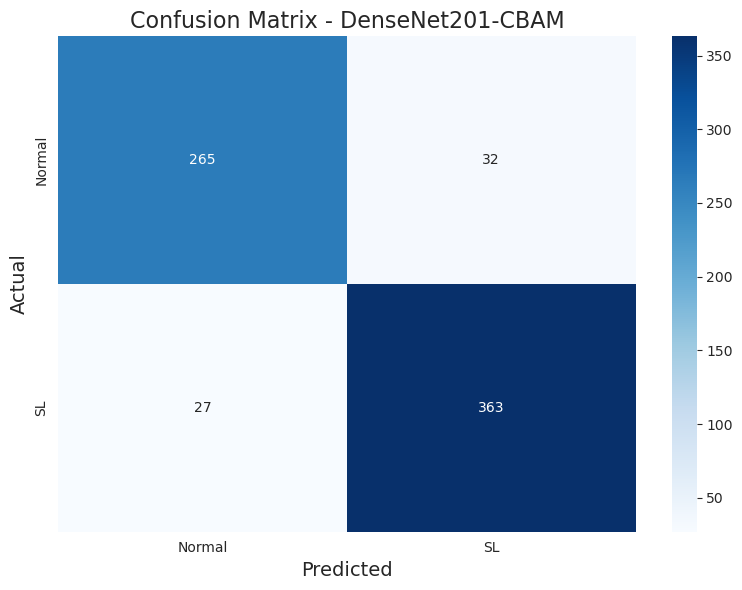

In [10]:
# =============================================================================
# SAVE HISTORY & PLOTS
# =============================================================================
hist_df = pd.DataFrame(history.history)
hist_df.to_csv('history_cbam.csv', index=False)

def plot_history(history, model_name='DenseNet201-CBAM'):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = np.arange(1, len(loss) + 1)

    plt.figure(figsize=(9, 5))
    plt.plot(epochs, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs, val_loss, label='Validation Loss', linewidth=2)
    plt.yscale('log')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss (Log Scale)', fontsize=12)
    plt.title(f'{model_name} Training Progress', fontsize=14)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.savefig(f'{model_name}_training_plot.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_history(history, 'DenseNet201-CBAM')

def plot_confusion_matrix(model, test_gen, model_name='Proposed Model'):
    y_pred_probs = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_gen.classes
    cm = confusion_matrix(y_true, y_pred)
    class_names = ['Normal', 'SL']

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual', fontsize=14)
    plt.xlabel('Predicted', fontsize=14)
    plt.title(f'Confusion Matrix - {model_name}', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'{model_name}_cm.jpg', dpi=300)
    plt.show()

plot_confusion_matrix(model, test_gen, 'DenseNet201-CBAM')

model.save('ag_densenet_cbam.h5')